# Geographic Scope and Analysis Regions

This notebook defines the spatial framework for all downstream biodiversity analyses.
It accomplishes two things:

1. Establishes Denmark as the geographic scope using official GADM boundary shapefiles
2. Implements two parallel spatial aggregation strategies:
   - **Strategy A:** Regular 0.1° grid overlay
   - **Strategy B:** Administrative region boundaries (Denmark's 5 regions)

Both strategies produce a version of the filtered occurrence dataset where every 
record has been assigned to a spatial unit. These two labelled datasets are saved 
and carried forward into all subsequent analyses (Task 3 onwards).

**Input:** `dofbasen_birds_filtered.parquet` (from Task 1)  
**Outputs:** 
- `grid_assigned.parquet` — records labelled with grid cell ID
- `admin_assigned.parquet` — records labelled with administrative region
- `denmark_grid.gpkg` — GeoPackage of grid cell geometries
- `denmark_admin.gpkg` — GeoPackage of administrative region geometries

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from shapely.geometry import Point, box

In [2]:
# Input: filtered occurrence data from Task 1
INPUT_PATH = "../dofbasen_birds_filtered.parquet"

# Denmark's geographic bounding box
# These are the approximate lat/lon extents of Denmark including all islands
DK_LAT_MIN, DK_LAT_MAX = 54.550, 57.750
DK_LON_MIN, DK_LON_MAX = 8.067,  15.183

# Grid resolution in decimal degrees
# 0.3 degrees ≈ 24km (latitude) x 18km (longitude) in Denmark
GRID_RESOLUTION = 0.3

# Output paths
GRID_ASSIGNED_PATH  = "../outputs/grid_assigned.parquet"
ADMIN_ASSIGNED_PATH = "../outputs/admin_assigned.parquet"
DENMARK_GRID_PATH   = "../outputs/denmark_grid.gpkg"
DENMARK_ADMIN_PATH  = "../outputs/denmark_admin.gpkg"

GADM_FOLDER = "../GADM Denmark Shapefile"

# Shapefile paths within that folder
GADM_LEVEL0 = f"{GADM_FOLDER}/gadm41_DNK_0.shp"  # National boundary
GADM_LEVEL1 = f"{GADM_FOLDER}/gadm41_DNK_1.shp"  # 5 Administrative regions

## Why Two Spatial Aggregation Strategies?

The choice of spatial unit is not neutral — it actively shapes what patterns 
you find. This is formally known as the **Modifiable Areal Unit Problem (MAUP)**: 
the same underlying point data can produce different apparent hotspots depending 
on how you aggregate it.

**Grid-based aggregation** divides Denmark into equal-sized square cells regardless 
of political boundaries. Every cell covers the same area, making richness values 
directly comparable without area-correction. The disadvantage is that grid cells 
have no real-world administrative meaning.

**Administrative aggregation** uses Denmark's 5 official regions, which are 
meaningful to policymakers and conservationists. The disadvantage is that regions 
vary enormously in size — Region Midtjylland is much larger than Region Hovedstaden 
— so raw richness counts are not directly comparable without area correction.

By running both strategies in parallel and comparing their results in Task 5 
(Intensification Requirement 2), we can assess whether our conclusions about 
biodiversity hotspots are robust to aggregation choice or are artefacts of it.

In [3]:
# Load the parquet file produced in Task 1
df = pd.read_parquet(INPUT_PATH)

print(f"Loaded dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn dtypes:\n{df.dtypes}")
print(f"\nFirst 3 rows:\n{df.head(3)}")

Loaded dataset: 30,172,537 rows × 20 columns

Column dtypes:
species                                     str
genus                                       str
family                                      str
order                                       str
class                                       str
taxonRank                                   str
decimalLatitude                         float64
decimalLongitude                        float64
coordinateUncertaintyInMeters           float64
eventDate                        datetime64[us]
year                                      Int64
month                                     Int64
day                                       Int64
individualCount                           Int64
occurrenceStatus                            str
hasCoordinate                               str
hasGeospatialIssues                         str
issue                                       str
recordedBy                                  str
countryCode                

In [4]:
print(f"Last 5 rows:\n{df.tail(5)}")

Last 5 rows:
                       species         genus        family            order  \
30172532       Mareca strepera        Mareca      Anatidae     Anseriformes   
30172533  Phoenicurus ochruros   Phoenicurus  Muscicapidae    Passeriformes   
30172534   Carduelis carduelis     Carduelis  Fringillidae    Passeriformes   
30172535   Spatula querquedula       Spatula      Anatidae     Anseriformes   
30172536  Hydrocoloeus minutus  Hydrocoloeus       Laridae  Charadriiformes   

         class taxonRank  decimalLatitude  decimalLongitude  \
30172532  Aves   SPECIES         54.93666           8.66157   
30172533  Aves   SPECIES         54.95271          12.54675   
30172534  Aves   SPECIES         55.93198          12.50780   
30172535  Aves   SPECIES         54.88022          10.03367   
30172536  Aves   SPECIES         54.59638          11.50005   

          coordinateUncertaintyInMeters  eventDate  year  month  day  \
30172532                         3270.0 2016-04-02  2016     

## Loading Denmark Boundary Data from GADM

GADM (Global Administrative Areas) provides free, research-grade administrative 
boundary shapefiles for every country. We download the Denmark shapefile directly 
from their server. The ZIP archive contains multiple shapefiles at different 
administrative levels:

- Level 0 (`gadm41_DNK_0`): Single national boundary polygon
- Level 1 (`gadm41_DNK_1`): 5 regional boundaries
- Level 2 (`gadm41_DNK_2`): 98 municipal boundaries

We use Level 0 to define our geographic scope and Level 1 for administrative 
aggregation (Strategy B). We use Level 1 rather than Level 2 because 98 
municipalities would produce many cells with very sparse records, making 
statistical comparisons unreliable.

National boundary loaded.
CRS: EPSG:4326
Number of polygons: 1


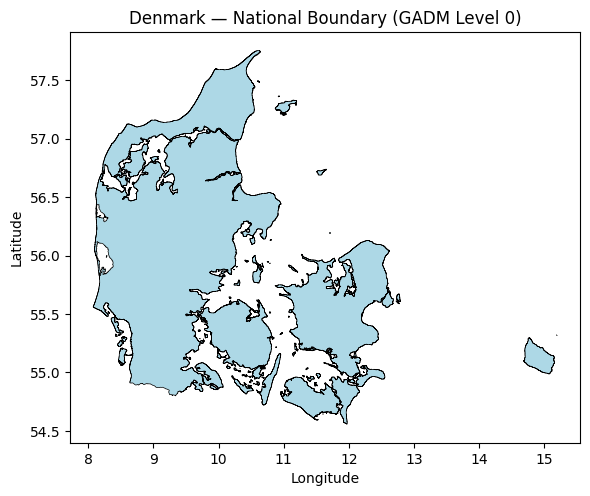

In [5]:
# Load national boundary (Level 0) directly from local shapefile
denmark_boundary = gpd.read_file(GADM_LEVEL0)
denmark_boundary = denmark_boundary.to_crs(epsg=4326)

print(f"National boundary loaded.")
print(f"CRS: {denmark_boundary.crs}")
print(f"Number of polygons: {len(denmark_boundary)}")

# Quick plot to verify
fig, ax = plt.subplots(figsize=(6, 8))
denmark_boundary.plot(ax=ax, color="lightblue", edgecolor="black", linewidth=0.5)
ax.set_title("Denmark — National Boundary (GADM Level 0)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig("../outputs/denmark_boundary.png", dpi=150)
plt.show()

Region shapefile columns:
['GID_1', 'GID_0', 'COUNTRY', 'NAME_1', 'VARNAME_1', 'NL_NAME_1', 'TYPE_1', 'ENGTYPE_1', 'CC_1', 'HASC_1', 'ISO_1', 'geometry']

Number of regions: 5

Region names:
        NAME_1
0  Hovedstaden
1  Midtjylland
2  Nordjylland
3     Sjælland
4   Syddanmark


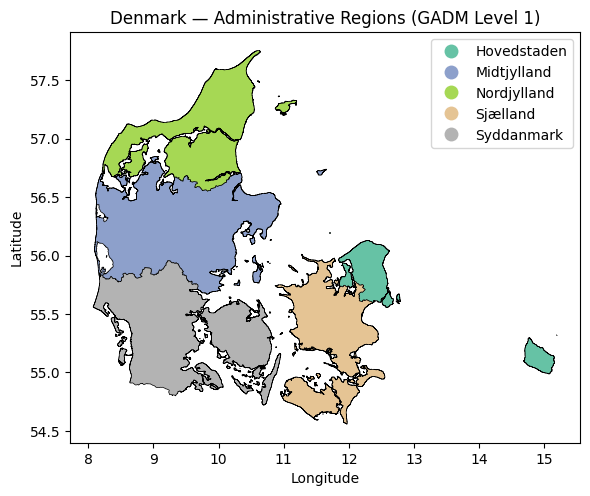

In [6]:
# Load the 5 administrative regions
denmark_regions = gpd.read_file("gadm_temp/gadm41_DNK_1.shp")
denmark_regions = denmark_regions.to_crs(epsg=4326)

# Inspect the columns — we need the region name column for labelling
print("Region shapefile columns:")
print(denmark_regions.columns.tolist())
print(f"\nNumber of regions: {len(denmark_regions)}")
print(f"\nRegion names:\n{denmark_regions[['NAME_1']].to_string()}")

# Plot to verify all 5 regions are present and correctly shaped
fig, ax = plt.subplots(figsize=(6, 8))
denmark_regions.plot(
    ax=ax, column="NAME_1", cmap="Set2",
    edgecolor="black", linewidth=0.5, legend=True
)
ax.set_title("Denmark — Administrative Regions (GADM Level 1)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig("../outputs/denmark_regions.png", dpi=150)
plt.show()

## Strategy A — Regular Grid Overlay

We divide Denmark's bounding box into cells of 0.3° × 0.3°. Each cell is 
identified by a unique string ID formed from its **lower-left corner** coordinates, 
e.g. `"lat_55.0_lon_12.0"`.

Assigning records to grid cells does not require a spatial join — it is a simple 
arithmetic operation: round each coordinate down to the nearest grid boundary. 
This is computationally very fast even on millions of records.

The grid is then clipped to Denmark's national boundary so that ocean cells and 
cells belonging to neighbouring countries are excluded. This is important because 
without clipping, coastal grid cells would appear to cover large ocean areas, 
making their species richness look artificially low relative to their actual 
land area.

In [7]:
# Compute grid cell lower-left corner for each record
# Floor division by resolution, then multiply back, gives the lower-left corner of the grid cell that each point falls into
df["lat_bin"] = (df["decimalLatitude"]  // GRID_RESOLUTION) * GRID_RESOLUTION
df["lon_bin"] = (df["decimalLongitude"] // GRID_RESOLUTION) * GRID_RESOLUTION

# Create a unique string cell ID from the bin coordinates
# Round to 4 decimal places to avoid floating point representation issues
# e.g. "lat_55.0000_lon_12.1000"
df["grid_cell_id"] = (
    "lat_" + df["lat_bin"].round(4).astype(str) +
    "_lon_" + df["lon_bin"].round(4).astype(str)
)

print(f"Unique grid cells with at least one record: {df['grid_cell_id'].nunique():,}")
print(f"\nSample cell IDs:\n{df['grid_cell_id'].value_counts().head(10)}")

Unique grid cells with at least one record: 204

Sample cell IDs:
grid_cell_id
lat_55.5_lon_12.3    2921914
lat_55.8_lon_11.7    1208531
lat_55.8_lon_12.3    1181183
lat_57.6_lon_10.5     951056
lat_55.8_lon_12.0     829639
lat_55.5_lon_12.0     807235
lat_55.2_lon_8.4      680047
lat_55.2_lon_12.0     611381
lat_55.5_lon_7.8      511693
lat_54.9_lon_8.4      510402
Name: count, dtype: int64


Grid cells before clipping: 204
Grid cells after clipping to Denmark: 134
Grid geometry saved to '../outputs/denmark_grid.gpkg'


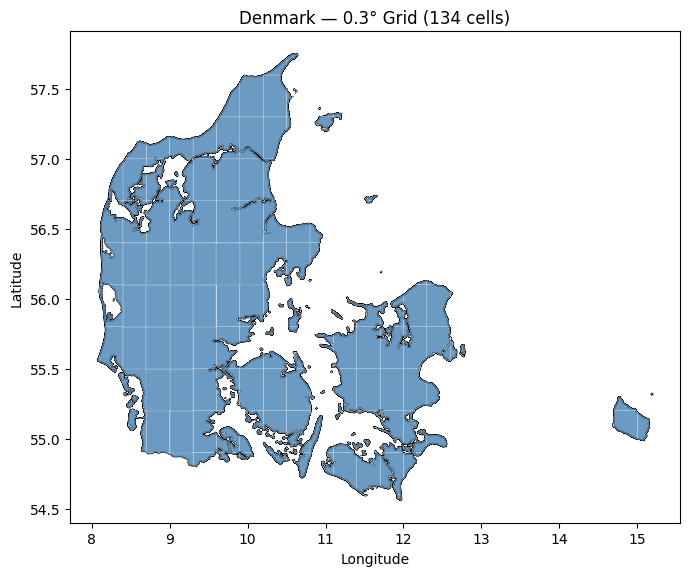

In [8]:
# Build a GeoDataFrame of all grid cell polygons
# For each unique (lat_bin, lon_bin) pair, create a square polygon

unique_cells = df[["lat_bin", "lon_bin", "grid_cell_id"]].drop_duplicates()

# Create a shapely box polygon for each cell
# box(minx, miny, maxx, maxy)
unique_cells["geometry"] = unique_cells.apply(
    lambda row: box(
        row["lon_bin"],                        # minx (left edge)
        row["lat_bin"],                        # miny (bottom edge)
        row["lon_bin"] + GRID_RESOLUTION,      # maxx (right edge)
        row["lat_bin"] + GRID_RESOLUTION       # maxy (top edge)
    ),
    axis=1
)

grid_gdf = gpd.GeoDataFrame(unique_cells, geometry="geometry", crs="EPSG:4326")

print(f"Grid cells before clipping: {len(grid_gdf):,}")

# Clip grid to Denmark's national boundary
# This removes cells that fall entirely outside Denmark (ocean, neighbouring countries)
# gpd.clip keeps cells that intersect the boundary, trimming cells at the coast
grid_gdf_clipped = gpd.clip(grid_gdf, denmark_boundary)

print(f"Grid cells after clipping to Denmark: {len(grid_gdf_clipped):,}")

# Save the grid geometry for use in the dashboard and later analyses
grid_gdf_clipped.to_file(DENMARK_GRID_PATH, driver="GPKG")
print(f"Grid geometry saved to '{DENMARK_GRID_PATH}'")

# Plot the clipped grid
fig, ax = plt.subplots(figsize=(7, 9))
denmark_boundary.plot(ax=ax, color="none", edgecolor="black", linewidth=1)
grid_gdf_clipped.plot(ax=ax, color="steelblue", edgecolor="white",
                      linewidth=0.2, alpha=0.8)
ax.set_title(f"Denmark — 0.3° Grid ({len(grid_gdf_clipped):,} cells)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig("../outputs/denmark_grid.png", dpi=1600)
plt.show()

In [9]:
# Keep only records whose grid_cell_id appears in the clipped grid
# This removes any records that fell in ocean cells or outside Denmark's boundary
valid_cell_ids = set(grid_gdf_clipped["grid_cell_id"])
df_grid = df[df["grid_cell_id"].isin(valid_cell_ids)].copy()

print(f"Records before grid clipping : {len(df):,}")
print(f"Records after grid clipping  : {len(df_grid):,}")
print(f"Records removed              : {len(df) - len(df_grid):,}")

Records before grid clipping : 30,172,537
Records after grid clipping  : 30,138,961
Records removed              : 33,576


In [10]:
# Save the grid-assigned dataset
df_grid.to_parquet(GRID_ASSIGNED_PATH, index=False)
print(f"\nGrid-assigned dataset saved to '{GRID_ASSIGNED_PATH}'")


Grid-assigned dataset saved to '../outputs/grid_assigned.parquet'


## Strategy B — Administrative Region Assignment

We assign each record to one of Denmark's 5 administrative regions using a 
**spatial join** (`geopandas.sjoin`). This operation checks, for each point, 
which polygon it falls inside, and attaches that polygon's attributes to the point.

To perform a spatial join, we must first convert our occurrence DataFrame into 
a GeoDataFrame — a pandas DataFrame with a geometry column containing shapely 
Point objects built from the lat/lon coordinates.

The spatial join is more computationally expensive than the grid assignment 
(it performs polygon containment checks rather than simple arithmetic), but 
it is still fast enough for millions of records when using geopandas's 
optimised spatial indexing.

In [11]:
import pyarrow as pa
import pyarrow.parquet as pq

SJOIN_CHUNK_SIZE = 200_000
parquet_writer   = None
total_chunks     = len(df) // SJOIN_CHUNK_SIZE + 1
total_matched    = 0
total_unmatched  = 0

# Reproject regions ONCE before the loop — into metres (UTM Zone 32N, EPSG:25832)
# This is reused across all chunks that have unmatched coastal records
# so we are not reprojecting the same 5 polygons hundreds of times
denmark_regions_proj = denmark_regions[["NAME_1", "geometry"]].to_crs(epsg=25832)

for i, start in enumerate(range(0, len(df), SJOIN_CHUNK_SIZE)):

    chunk = df.iloc[start : start + SJOIN_CHUNK_SIZE].copy()

    # Convert chunk to GeoDataFrame in EPSG:4326 (degrees — matches occurrence data)
    gdf_chunk = gpd.GeoDataFrame(
        chunk,
        geometry=gpd.points_from_xy(
            chunk["decimalLongitude"],
            chunk["decimalLatitude"]
        ),
        crs="EPSG:4326"
    )

    # Spatial join: assign each point to the region it falls WITHIN
    # how="left" keeps all records even if no polygon match is found
    # predicate="within" tests whether the point is inside the polygon
    joined = gpd.sjoin(
        gdf_chunk,
        denmark_regions[["NAME_1", "geometry"]],
        how="left",
        predicate="within"
    ).rename(columns={"NAME_1": "admin_region"})

    # Drop index_right column added by sjoin — not needed
    if "index_right" in joined.columns:
        joined = joined.drop(columns=["index_right"])

    # ── Resolve unmatched coastal records ────────────────────────────────────
    # Records that did not fall inside any polygon are typically coastal points whose coordinates land just outside the polygon boundary due to GPS rounding.
    # We use sjoin_nearest to assign them to the closest region.

    # Note: sjoin_nearest must be run in a PROJECTED CRS (metres, EPSG:25832), not a geographic CRS (degrees, EPSG:4326)
    # This is because distance calculations in degrees are geometrically incorrect — a degree of longitude in Denmark is ~62km but a degree of latitude is ~111km, so degree-based distances
    # are distorted.
    # Projecting to UTM Zone 32N gives correct metre-based distances.

    unmatched_mask = joined["admin_region"].isna()

    if unmatched_mask.sum() > 0:

        # Extract unmatched rows — these still have geometry from gdf_chunk
        gdf_unmatched = joined[unmatched_mask].copy()

        # Make sure geometry column is set correctly for geopandas operations
        gdf_unmatched = gpd.GeoDataFrame(gdf_unmatched, geometry="geometry", crs="EPSG:4326")

        # Reproject unmatched points from degrees to metres
        gdf_unmatched_proj = gdf_unmatched.to_crs(epsg=25832)

        # Find nearest region polygon for each unmatched point
        nearest = gpd.sjoin_nearest(
            gdf_unmatched_proj[["geometry"]],   # only need geometry for the join
            denmark_regions_proj,               # already in metres from before loop
            how="left"
        ).rename(columns={"NAME_1": "admin_region_nearest"})

        # Patch the NaN admin_region values in joined with the nearest result
        joined.loc[unmatched_mask, "admin_region"] = \
            nearest["admin_region_nearest"].values

        del gdf_unmatched, gdf_unmatched_proj, nearest

    # Track counts for the summary at the end
    total_unmatched += joined["admin_region"].isna().sum()
    total_matched   += joined["admin_region"].notna().sum()

    # Convert to plain DataFrame — drop geometry column immediately to free RAM
    # The geometry is no longer needed once the region name has been assigned
    chunk_result = pd.DataFrame(
        joined.drop(columns=["geometry"], errors="ignore")
    )

    # Write this chunk directly to the Parquet file on disk
    # Never accumulate in a list — that is what caused the kernel crash before
    table = pa.Table.from_pandas(chunk_result, preserve_index=False)

    if parquet_writer is None:
        # First chunk: create the Parquet file and write the schema header
        parquet_writer = pq.ParquetWriter(ADMIN_ASSIGNED_PATH, table.schema)
        print(f"  [First chunk] Parquet file created at '{ADMIN_ASSIGNED_PATH}'")

    parquet_writer.write_table(table)

    # Explicitly delete all chunk-level objects before next iteration
    del chunk, gdf_chunk, joined, chunk_result, table

    print(f"  Chunk {i+1}/{total_chunks} written — "
          f"rows {start:,} to {min(start + SJOIN_CHUNK_SIZE, len(df)):,}")

# Finalise and close the Parquet file
if parquet_writer:
    parquet_writer.close()

print(f"\n{'='*55}")
print(f"  Spatial join complete.")
print(f"  Total records matched   : {total_matched:,}")
print(f"  Total records unmatched : {total_unmatched:,}")
print(f"  Saved to                : '{ADMIN_ASSIGNED_PATH}'")
print(f"{'='*55}")

  [First chunk] Parquet file created at '../outputs/admin_assigned.parquet'
  Chunk 1/151 written — rows 0 to 200,000
  Chunk 2/151 written — rows 200,000 to 400,000
  Chunk 3/151 written — rows 400,000 to 600,000
  Chunk 4/151 written — rows 600,000 to 800,000
  Chunk 5/151 written — rows 800,000 to 1,000,000
  Chunk 6/151 written — rows 1,000,000 to 1,200,000
  Chunk 7/151 written — rows 1,200,000 to 1,400,000
  Chunk 8/151 written — rows 1,400,000 to 1,600,000
  Chunk 9/151 written — rows 1,600,000 to 1,800,000
  Chunk 10/151 written — rows 1,800,000 to 2,000,000
  Chunk 11/151 written — rows 2,000,000 to 2,200,000
  Chunk 12/151 written — rows 2,200,000 to 2,400,000
  Chunk 13/151 written — rows 2,400,000 to 2,600,000
  Chunk 14/151 written — rows 2,600,000 to 2,800,000
  Chunk 15/151 written — rows 2,800,000 to 3,000,000
  Chunk 16/151 written — rows 3,000,000 to 3,200,000
  Chunk 17/151 written — rows 3,200,000 to 3,400,000
  Chunk 18/151 written — rows 3,400,000 to 3,600,000
  C